# Part 2: Computer Vision Problem Formulation and CNN Prototype

### Problem Statement:
You are given an image-based dataset. Your task is to formulate a computer vision problem and build a basic CNN-based prototype to solve it.

The focus of this part is to understand how CNNs use convolution, pooling, activation functions, and dense layers to learn visual patterns from images.

## Task 1: Problem Identification:

This dataset represents an **Image Classification** problem.

Reason:
- Each image belongs to one category only.
- The goal is to predict a single label for the entire image.
- We are not locating objects or segmenting pixels.

## Task 2: Dataset Exploration

In [1]:
# Importing basic libraries for data handling
import os
import numpy as np
import pandas as pd

# Importing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Importing image processing libraries
from PIL import Image

# TensorFlow / Keras libraries for deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# Libraries for model evaluation
from sklearn.metrics import confusion_matrix, classification_report

# Ignore warnings for cleaner notebook output
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Defining the main dataset path

dataset_path = "images"

# Listing all class folders inside the dataset directory
classes = os.listdir(dataset_path)

# Display class names
print("Classes Found:")
print(classes)

Classes Found:
['dent', 'normal', 'scratch', 'stain']


In [3]:
# Counting number of images in each class

image_count = {}

for cls in classes:
    
    # Creating full folder path
    folder_path = os.path.join(dataset_path, cls)
    
    # Counting images inside the folder
    count = len(os.listdir(folder_path))
    
    image_count[cls] = count

# Convert to dataframe for better visualization
count_df = pd.DataFrame(
    image_count.items(),
    columns=["Class", "Image Count"]
)

# Display dataframe
print(count_df)

     Class  Image Count
0     dent          120
1   normal          120
2  scratch          120
3    stain          120


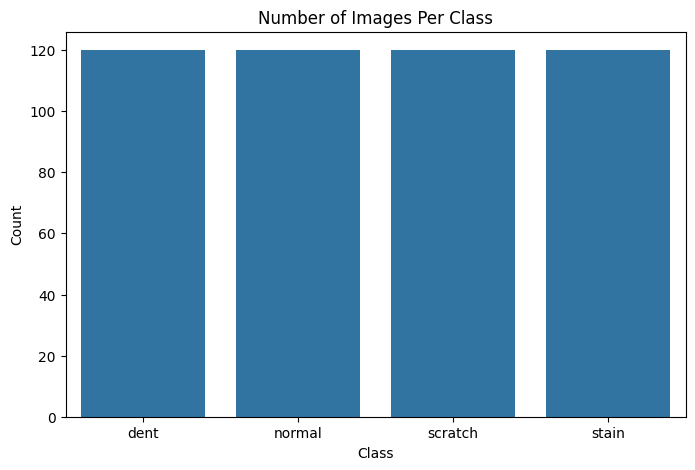

In [4]:
# Plotting dataset distribution

plt.figure(figsize=(8,5))

sns.barplot(
    x="Class",
    y="Image Count",
    data=count_df
)

plt.title("Number of Images Per Class")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

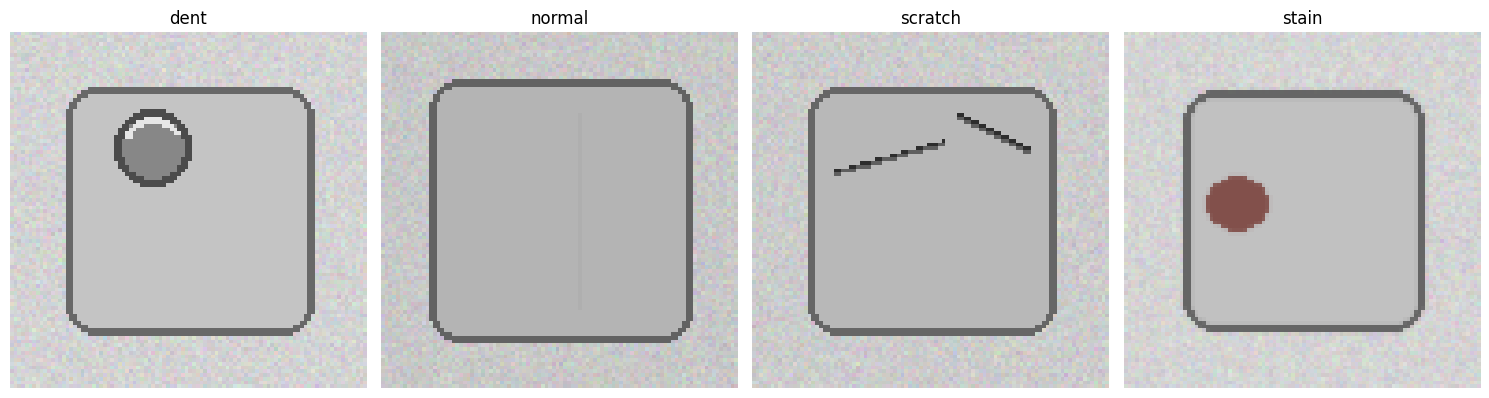

In [5]:
# Displaying one sample image from each class

plt.figure(figsize=(15,5))

for i, cls in enumerate(classes):
    
    # Get image path
    img_name = os.listdir(os.path.join(dataset_path, cls))[0]
    
    img_path = os.path.join(dataset_path, cls, img_name)
    
    # Load image
    img = Image.open(img_path)
    
    # Plot image
    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Checking image dimensions from each class

for cls in classes:
    
    # Select first image from folder
    img_name = os.listdir(os.path.join(dataset_path, cls))[0]
    
    img_path = os.path.join(dataset_path, cls, img_name)
    
    # Open image
    img = Image.open(img_path)
    
    print(f"{cls} image size: {img.size}")

dent image size: (96, 96)
normal image size: (96, 96)
scratch image size: (96, 96)
stain image size: (96, 96)


# Task 3: Image Preprocessing

The preprocessing steps include:

1. Resizing images to fixed dimensions
2. Normalizing pixel values
3. Splitting data into training and validation sets
4. Applying data augmentation

These steps help improve model performance and generalization.

In [7]:
# Defining image size and batch size

IMG_HEIGHT = 128
IMG_WIDTH = 128

BATCH_SIZE = 32

In [8]:
# ImageDataGenerator automatically:
# - loads images
# - rescales pixel values
# - performs augmentation
# - creates training and validation batches

train_datagen = ImageDataGenerator(
    
    # Normalize pixel values between 0 and 1
    rescale=1./255,
    
    # Data augmentation
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    
    # Create validation split
    validation_split=0.2
)

In [9]:
# Creating training data generator

train_generator = train_datagen.flow_from_directory(
    
    dataset_path,
    
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    
    batch_size=BATCH_SIZE,
    
    class_mode='categorical',
    
    subset='training'
)

Found 384 images belonging to 4 classes.


In [10]:
# Creating validation data generator

validation_generator = train_datagen.flow_from_directory(
    
    dataset_path,
    
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    
    batch_size=BATCH_SIZE,
    
    class_mode='categorical',
    
    subset='validation'
)

Found 96 images belonging to 4 classes.


## Task 4: CNN Model Creation

In [11]:
# Creating CNN model

model = Sequential()

# First convolution layer
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

# First pooling layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second convolution layer
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

# Second pooling layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Third convolution layer
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

# Third pooling layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten layer converts feature maps into 1D vector
model.add(Flatten())

# Dense layer
model.add(Dense(128, activation='relu'))

# Dropout helps reduce overfitting
model.add(Dropout(0.5))

# Output layer
# 4 neurons because we have 4 classes
model.add(Dense(4, activation='softmax'))

## Task 5: Model Training and Evaluation

In [12]:
# Compiling the CNN model

model.compile(
    
    optimizer='adam',
    
    loss='categorical_crossentropy',
    
    metrics=['accuracy']
)

In [13]:
# Displaying model architecture summary

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 14, 14, 128)       0

In [14]:
import scipy
print(scipy.__version__)

1.15.3


In [15]:
# Training the CNN model

history = model.fit(
    
    train_generator,
    
    validation_data=validation_generator,
    
    epochs=15
)

Epoch 1/15


12/12 [==============================] - 7s 428ms/step - loss: 1.5408 - accuracy: 0.2396 - val_loss: 1.3811 - val_accuracy: 0.4792
Epoch 2/15
12/12 [==============================] - 5s 390ms/step - loss: 1.3738 - accuracy: 0.3021 - val_loss: 1.3419 - val_accuracy: 0.2500
Epoch 3/15
12/12 [==============================] - 4s 363ms/step - loss: 1.2660 - accuracy: 0.3958 - val_loss: 1.1092 - val_accuracy: 0.5833
Epoch 4/15
12/12 [==============================] - 4s 330ms/step - loss: 0.9808 - accuracy: 0.5807 - val_loss: 0.8020 - val_accuracy: 0.6979
Epoch 5/15
12/12 [==============================] - 4s 325ms/step - loss: 0.7830 - accuracy: 0.6719 - val_loss: 0.6165 - val_accuracy: 0.7812
Epoch 6/15
12/12 [==============================] - 4s 335ms/step - loss: 0.6947 - accuracy: 0.7188 - val_loss: 0.5156 - val_accuracy: 0.8438
Epoch 7/15
12/12 [==============================] - 4s 323ms/step - loss: 0.5558 - accuracy: 0.7891 - val_loss: 0.3863 - val_accuracy: 0.8854
Epoc

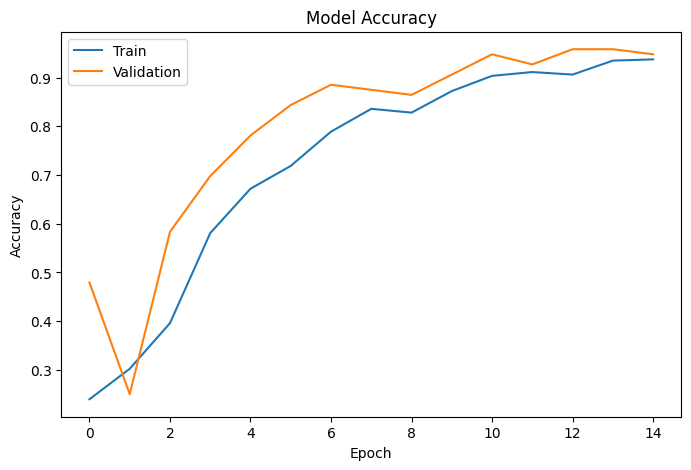

In [16]:
# Plotting training and validation accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

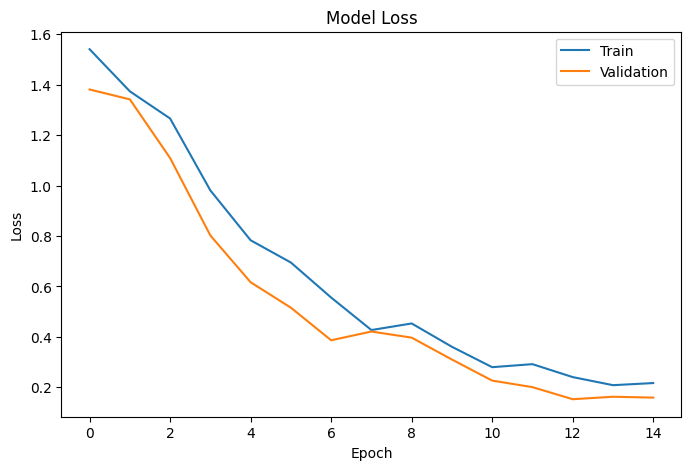

In [17]:
# Plotting training and validation loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

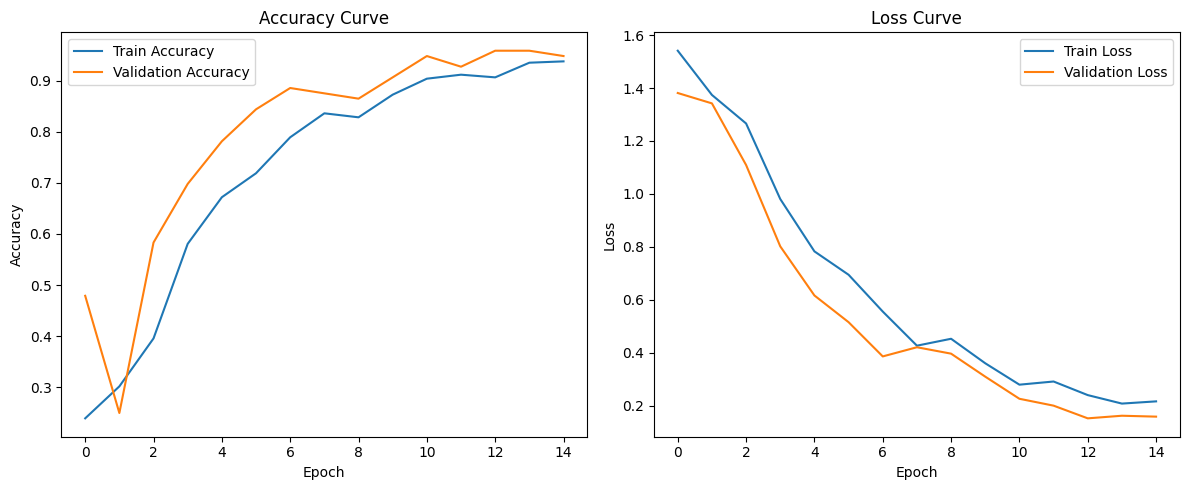

accuracy_loss_curves.png saved successfully


In [18]:
# Plotting and saving accuracy/loss curves

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

# Loss plot
plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

# Save figure
plt.savefig("results/accuracy_loss_curves.png")

plt.show()

print("accuracy_loss_curves.png saved successfully")

In [19]:
# Evaluating model performance

loss, accuracy = model.evaluate(validation_generator)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

3/3 [==============================] - 1s 158ms/step - loss: 0.1332 - accuracy: 0.9479
Validation Loss: 0.13317491114139557
Validation Accuracy: 0.9479166865348816


In [20]:
# Generating predictions on validation dataset

predictions = model.predict(validation_generator)

# Convert probabilities into class labels
predicted_classes = np.argmax(predictions, axis=1)

# Actual labels
true_classes = validation_generator.classes

3/3 [==============================] - 1s 150ms/step


### Confusion Matrix:

Required: true_classes and predicted_classes

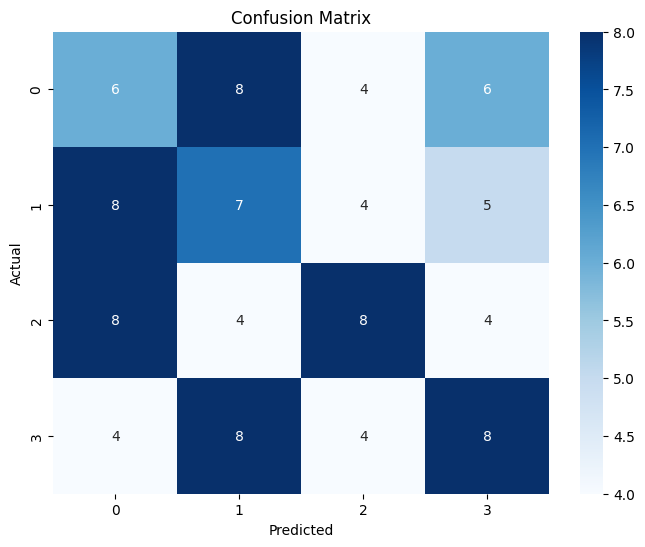

confusion_matrix.png saved successfully


In [21]:
# Create confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Save confusion matrix image
plt.savefig("results/confusion_matrix.png")

plt.show()

print("confusion_matrix.png saved successfully")

In [22]:
# Printing classification report

class_labels = list(validation_generator.class_indices.keys())

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_labels
    )
)

              precision    recall  f1-score   support

        dent       0.23      0.25      0.24        24
      normal       0.26      0.29      0.27        24
     scratch       0.40      0.33      0.36        24
       stain       0.35      0.33      0.34        24

    accuracy                           0.30        96
   macro avg       0.31      0.30      0.30        96
weighted avg       0.31      0.30      0.30        96



## Display and Save sample predictions

Getting the batch of images from this dataset: validation_generator

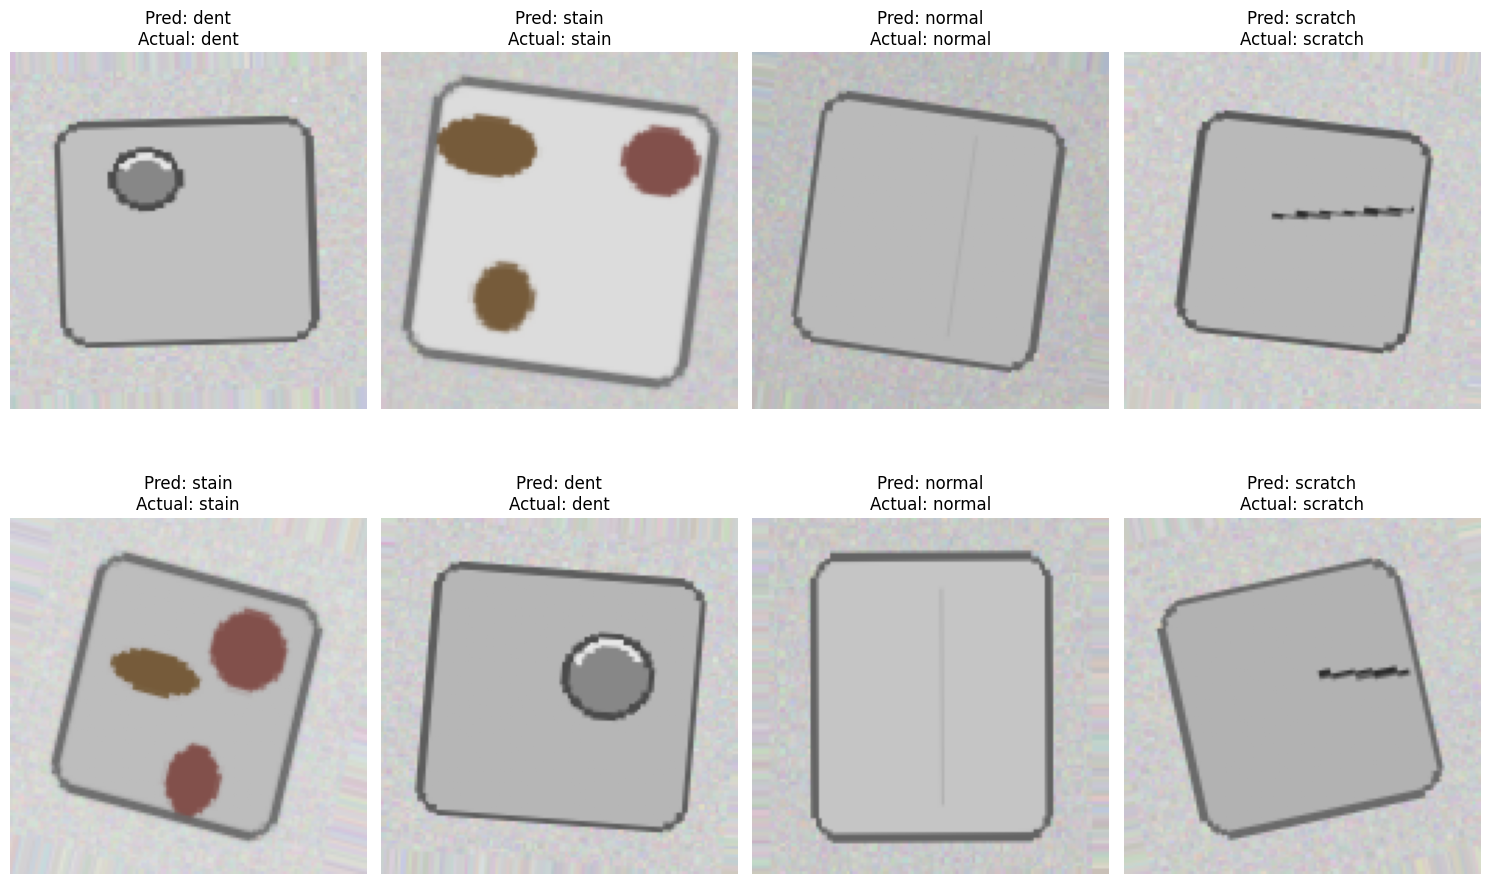

prediction_outputs.png saved successfully


In [23]:
# Displaying and saving sample predictions

plt.figure(figsize=(15,10))

for i in range(8):

    # Get batch of images
    images, labels = next(validation_generator)

    # Predict class
    pred = model.predict(images, verbose=0)

    pred_class = np.argmax(pred[0])
    actual_class = np.argmax(labels[0])

    pred_label = class_labels[pred_class]
    actual_label = class_labels[actual_class]

    # Plot image
    plt.subplot(2,4,i+1)

    plt.imshow(images[0])

    plt.title(
        f"Pred: {pred_label}\nActual: {actual_label}"
    )

    plt.axis("off")

plt.tight_layout()

# Save predictions image
plt.savefig("sample_predictions/prediction_outputs.png")

plt.show()

print("prediction_outputs.png saved successfully")

In [24]:
# Saving trained model

model.save("cnn_defect_classifier.h5")

print("Model Saved Successfully")

Model Saved Successfully
